In [2]:
import matplotlib.pyplot as plt
import numpy as np
import os 
from pathlib import Path
import torch 

import m2aia as m2
from ims_contrastive_model import IMSPyTorchDataset, IMSContrastiveModel 

# seting global dir
cwd=Path.cwd()
if cwd.name == "tutorials":
    # os.chdir(cwd.parent.parent) 
    os.chdir(cwd.parent) 
os.getcwd()

'/home/maxi7524/repositories/pym2aia_test'

In [3]:
# data loading 
PATH_DATA = Path('data')
PATH_sim_data = PATH_DATA / 'simulation_data' / 'test_4_final.imzML'
print(PATH_sim_data.exists())
PATH_real_data = PATH_DATA / 'bladder_data' / 'mouse_bladder.imzML'
print(PATH_real_data.exists())

# load data - IMPORTANT (NEED TO PASS STR)
reader_real = m2.ImzMLReader(str(PATH_real_data))

True
True
!Wed Apr 22 02:06:10 2026 
4.855! WARNING: No pixel size found, set x and y spacing to 50 microns!
!7.483! WARNING: Processed profile spectrum is not fully supported! Check the ImzML file.
[8.601] [imzML]: data/bladder_data/mouse_bladder.imzML
	[pixel size (mm)]: 0.050000x0.050000x0.010000
	[image dimension]: 260x134x1
	[num spectra]: 34840
	[spec. type]: ProcessedProfile
	[mass range]: 400.259620 to 999.795899 with #1500 measurements


In [4]:
Loader = IMSPyTorchDataset(reader_real, PATH_real_data.with_suffix(''))
model = IMSContrastiveModel(Loader, 64, epochs=1)

In [5]:
model.load(PATH_real_data.with_suffix(''))

[Load]: Model loaded from data/bladder_data/mouse_bladder
[Load]: Model loaded successfully from data/bladder_data/mouse_bladder


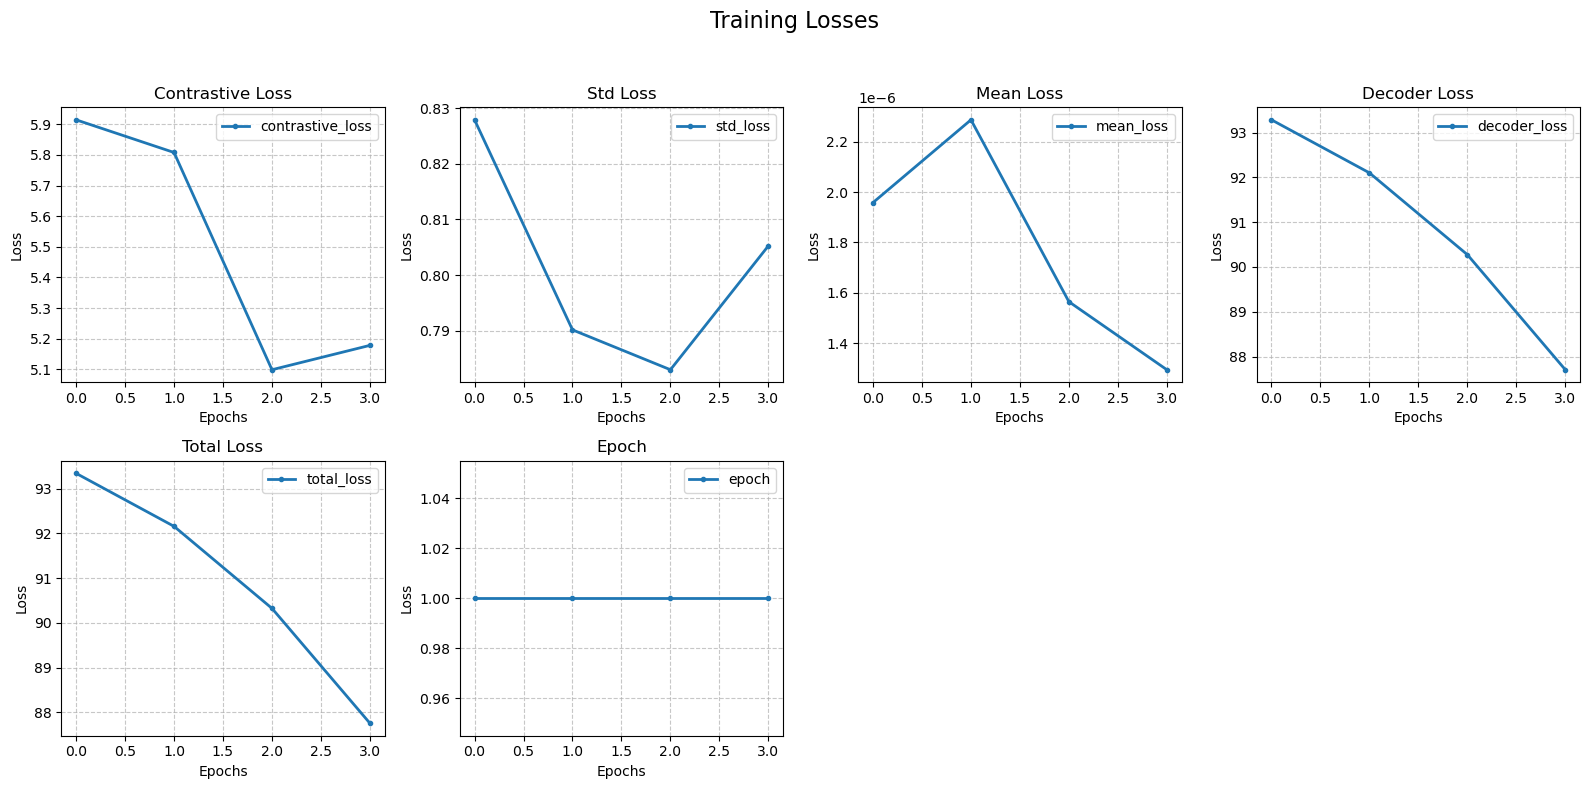

In [8]:
model.plot_epoch_losses()

In [5]:
model._batch_size = 128
model.fit(Loader.data_path)

[fit]: Continue training on loaded model ...
[save]: Model is saved
Epoch 1/1 | Loss: 87.7593 | Patience: 0/5


In [16]:
model.transform()

[Model] Transforming image to latent space...


RuntimeError: Tensor on device meta is not on the expected device cuda:0!